
# Climate + Environmental Integration for Biodiversity Forecasting

This notebook extends the existing biodiversity forecasting pipeline with a **clean country-year environmental panel** and keeps the workflow split into two clear goals:

1. **Forecasting**: compare the baseline lag-based biodiversity model vs the same model augmented with environmental features.
2. **Driver interpretation**: for a **single population**, fit a **climate-only / environment-only** model (no biodiversity lags, no non-climatic metadata) and rank the **top 3 environmental drivers** of its trend.

The notebook is intentionally modular:
- every external dataset is cleaned separately;
- country names are normalized once;
- all sources are merged into one global country-year panel;
- the forecasting and interpretation steps are run on top of that shared panel.



## 1. Design choices

### Core global environmental features kept in the notebook
- `temp_avg_c` → temperature
- `precip_mm` → precipitation / water availability
- `forest_share_pct` → habitat cover
- `forest_change_ha` → land-cover dynamics / deforestation-reforestation pressure
- `agricultural_land_log1p` → land-use pressure
- `wildfire_area_ha_per_fire_log1p` → disturbance / fire intensity

### Datasets intentionally excluded from the core climate block
- `mass-us-glaciers.csv` is **not** country-year global; it is a U.S.-glacier-specific series.
- `urban-population-share-2050.csv` is useful as an optional **human-pressure** feature, but it is not a core climatic/environmental driver and includes future projections.

### Missing-data strategy
- We interpolate **within country and only inside observed ranges** for the broad country-year environmental series.
- We do **not** extrapolate outside the observed range.
- Wildfire is left mostly as observed (very recent and sparse), then handled by the model imputer when still missing.


In [11]:

from pathlib import Path
import warnings
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    XGBRegressor = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
print("xgboost available:", HAS_XGBOOST)


xgboost available: True


In [12]:

# ---------------------------------------------------------
# PATHS & GLOBAL CONFIG
# ---------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()

DEFAULT_BIODIVERSITY_PATH = (
    PROJECT_ROOT / "data" / "interim" / "strict_forecasting" /
    "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv"
)

CLIMATE_CANDIDATE_DIRS = [
    PROJECT_ROOT / "data" / "external" / "climate",
    Path.cwd(),
    Path("/mnt/data"),
]

N_LAGS = 4
TEST_YEARS = 5
RANDOM_STATE = 42
LOCAL_MIN_SERIES_ROWS = 12

def resolve_input_file(filename, candidate_dirs=None):
    candidate_dirs = candidate_dirs or CLIMATE_CANDIDATE_DIRS
    for d in candidate_dirs:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{filename}'. Checked: {[str(d) for d in candidate_dirs]}"
    )

if not DEFAULT_BIODIVERSITY_PATH.exists():
    print("WARNING: biodiversity file not found at the default path.")
    print("Update DEFAULT_BIODIVERSITY_PATH before running the notebook locally.")
else:
    print("Biodiversity file:", DEFAULT_BIODIVERSITY_PATH)

for d in CLIMATE_CANDIDATE_DIRS:
    print("Climate search dir:", d)


Biodiversity file: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv
Climate search dir: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate
Climate search dir: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\notebooks
Climate search dir: \mnt\data


In [13]:

# ---------------------------------------------------------
# CLIMATE / ENVIRONMENT SOURCE CONFIGURATION
# ---------------------------------------------------------
ENV_SOURCES = {
    "temperature": {
        "filename": "average-annual-surface-temperature.csv",
        "value_col": "Average surface temperature",
        "raw_col": "temp_avg_c",
        "model_col": "temp_avg_c",
        "category": "temperature",
        "enabled": True,
        "year_min": None,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "precipitation": {
        "filename": "average-precipitation-per-year.csv",
        "value_col": "Annual precipitation",
        "raw_col": "precip_mm",
        "model_col": "precip_mm",
        "category": "water",
        "enabled": True,
        "year_min": None,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "forest_share": {
        "filename": "forest-area-as-share-of-land-area.csv",
        "value_col": "Share of land covered by forest",
        "raw_col": "forest_share_pct",
        "model_col": "forest_share_pct",
        "category": "habitat_cover",
        "enabled": True,
        "year_min": 1990,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "forest_change": {
        "filename": "annual-change-forest-area.csv",
        "value_col": "Annual change in forest area",
        "raw_col": "forest_change_ha",
        "model_col": "forest_change_ha",
        "category": "habitat_change",
        "enabled": True,
        "year_min": 1991,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "agricultural_land": {
        "filename": "agricultural-land.csv",
        "value_col": "Agricultural land - Area (hectares)",
        "raw_col": "agricultural_land_ha",
        "model_col": "agricultural_land_log1p",
        "category": "land_use",
        "enabled": True,
        "year_min": 1961,
        "year_max": None,
        "transform": "log1p_nonnegative",
        "interpolate_inside": True,
    },
    "wildfire": {
        "filename": "annual-area-burnt-per-wildfire.csv",
        "value_col": "Annual area burnt per wildfire",
        "raw_col": "wildfire_area_ha_per_fire",
        "model_col": "wildfire_area_ha_per_fire_log1p",
        "category": "disturbance",
        "enabled": True,
        "year_min": 2012,
        "year_max": 2025,   # 2026 is incomplete in the OWID package
        "transform": "log1p_nonnegative",
        "interpolate_inside": False,
    },
    "urban_population_optional": {
        "filename": "urban-population-share-2050.csv",
        "value_col": "Share of population residing in urban areas",
        "raw_col": "urban_share_pct",
        "model_col": "urban_share_pct",
        "category": "human_pressure_optional",
        "enabled": False,
        "year_min": 1900,
        "year_max": 2023,   # historical window only
        "transform": None,
        "interpolate_inside": True,
    },
}

ACTIVE_ENV_SOURCES = {
    k: v for k, v in ENV_SOURCES.items()
    if v.get("enabled", False)
}

CLIMATE_CORE_FEATURES = [cfg["model_col"] for cfg in ACTIVE_ENV_SOURCES.values()]
print("Active environmental model features:", CLIMATE_CORE_FEATURES)


Active environmental model features: ['temp_avg_c', 'precip_mm', 'forest_share_pct', 'forest_change_ha', 'agricultural_land_log1p', 'wildfire_area_ha_per_fire_log1p']


In [14]:

# ---------------------------------------------------------
# BIODIVERSITY HELPERS
# ---------------------------------------------------------
def build_series_id(df):
    parts = []

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if "country" in df.columns:
        parts.append(df["country"].astype(str))

    if len(parts) == 0:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p

    return series_id


def wide_to_long(df, year_columns):
    id_columns = [col for col in df.columns if col not in year_columns]

    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()

    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id"] = build_series_id(long_df)
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df


def temporal_split(df, test_years=5):
    years = sorted(df["Year"].unique())
    test_year_values = years[-test_years:]

    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)

    return train_df, test_df, test_year_values


def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae = mae / max(np.mean(np.abs(y_true)), 1e-9)
    wape = np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1e-9)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
        "WAPE": wape,
        "sMAPE": smape,
    }


In [15]:

# ---------------------------------------------------------
# COUNTRY NORMALIZATION
# ---------------------------------------------------------
def normalize_country_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    x = re.sub(r"\s+", " ", x)

    country_fixes = {
        "usa": "united states",
        "us": "united states",
        "u.s.a.": "united states",
        "u.s.": "united states",
        "uk": "united kingdom",
        "czech republic": "czechia",
        "viet nam": "vietnam",
        "russian federation": "russia",
        "republic of korea": "south korea",
        "korea, republic of": "south korea",
        "korea, dem. people's rep.": "north korea",
        "democratic republic of the congo": "democratic republic of congo",
        "dr congo": "democratic republic of congo",
        "republic of the congo": "congo",
        "congo, rep.": "congo",
        "congo, dem. rep.": "democratic republic of congo",
        "swaziland": "eswatini",
        "syrian arab republic": "syria",
        "iran, islamic republic of": "iran",
        "lao pdr": "laos",
        "bolivia (plurinational state of)": "bolivia",
        "venezuela (bolivarian republic of)": "venezuela",
        "türkiye": "turkey",
        "myanmar (burma)": "myanmar",
        "cape verde": "cabo verde",
        "slovak republic": "slovakia",
        "occupied palestinian territory": "palestine",
        "state of palestine": "palestine",
        "moldova, republic of": "moldova",
        "brunei darussalam": "brunei",
    }

    return country_fixes.get(x, x)


def keep_country_rows(df, code_col="Code"):
    if code_col not in df.columns:
        return df.copy()

    out = df.copy()
    out[code_col] = out[code_col].astype(str)
    out = out[out[code_col].str.fullmatch(r"[A-Z]{3}", na=False)].copy()
    return out


In [33]:

# ---------------------------------------------------------
# ENVIRONMENTAL DATA CLEANING
# ---------------------------------------------------------
def clean_owid_country_year_feature(
    csv_path,
    value_col,
    raw_col,
    model_col,
    year_min=None,
    year_max=None,
    transform=None,
):
    df = pd.read_csv(csv_path)

    keep_cols = ["Entity", "Code", "Year", value_col]
    missing_cols = [c for c in keep_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {csv_path.name}: {missing_cols}")

    df = df[keep_cols].copy()
    df = keep_country_rows(df, code_col="Code")

    df = df.rename(columns={
        "Entity": "country_source",
        "Code": "country_code",
        "Year": "Year",
        value_col: raw_col,
    })

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    if year_min is not None:
        df = df[df["Year"] >= year_min].copy()
    if year_max is not None:
        df = df[df["Year"] <= year_max].copy()

    df[raw_col] = pd.to_numeric(df[raw_col], errors="coerce")
    df["country_norm"] = df["country_source"].apply(normalize_country_name)

    if transform is None:
        df[model_col] = df[raw_col]
    elif transform == "log1p_nonnegative":
        df[model_col] = np.log1p(df[raw_col].clip(lower=0))
    else:
        raise ValueError(f"Unsupported transform: {transform}")

    df = (
        df
        .sort_values(["country_norm", "Year"])
        .drop_duplicates(subset=["country_norm", "Year"], keep="last")
        .reset_index(drop=True)
    )

    return df


def interpolate_inside_country(df, feature_cols):
    out = df.sort_values(["country_norm", "Year"]).copy()
    for col in feature_cols:
        out[col] = (
            out.groupby("country_norm")[col]
            .transform(lambda s: s.interpolate(limit_area="inside"))
        )
    return out


def feature_coverage_summary(df, feature_cols, group_col="country_norm"):
    if not df.columns.is_unique:
        dupes = pd.Index(df.columns)[pd.Index(df.columns).duplicated()].unique().tolist()
        raise ValueError(f"Duplicate column names detected in dataframe: {dupes}")

    rows = []
    for col in feature_cols:
        if col not in df.columns:
            rows.append({
                "feature": col,
                "non_null_rows": np.nan,
                "share_non_null": np.nan,
                "countries_with_data": np.nan,
                "year_min_with_data": np.nan,
                "year_max_with_data": np.nan,
                "note": "feature not found in dataframe",
            })
            continue

        series = df[col]
        rows.append({
            "feature": col,
            "non_null_rows": int(series.notna().sum()),
            "share_non_null": float(series.notna().mean()),
            "countries_with_data": int(df.loc[series.notna(), group_col].nunique()) if group_col in df.columns else np.nan,
            "year_min_with_data": int(df.loc[series.notna(), "Year"].min()) if series.notna().any() else np.nan,
            "year_max_with_data": int(df.loc[series.notna(), "Year"].max()) if series.notna().any() else np.nan,
            "note": "",
        })
    return pd.DataFrame(rows).sort_values(
        ["share_non_null", "feature"],
        ascending=[False, True],
        na_position="last"
    )

In [17]:

# ---------------------------------------------------------
# LOAD ALL ENVIRONMENTAL SOURCES
# ---------------------------------------------------------
env_tables = {}
env_source_summary_rows = []

for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    file_path = resolve_input_file(cfg["filename"])

    cleaned = clean_owid_country_year_feature(
        csv_path=file_path,
        value_col=cfg["value_col"],
        raw_col=cfg["raw_col"],
        model_col=cfg["model_col"],
        year_min=cfg["year_min"],
        year_max=cfg["year_max"],
        transform=cfg["transform"],
    )

    env_tables[source_name] = cleaned

    env_source_summary_rows.append({
        "source": source_name,
        "filename": cfg["filename"],
        "category": cfg["category"],
        "rows": len(cleaned),
        "countries": cleaned["country_norm"].nunique(),
        "year_min": cleaned["Year"].min(),
        "year_max": cleaned["Year"].max(),
        "raw_col": cfg["raw_col"],
        "model_col": cfg["model_col"],
    })

env_source_summary = pd.DataFrame(env_source_summary_rows).sort_values(["category", "source"])
display(env_source_summary)


,source,filename,category,rows,countries,year_min,year_max,raw_col,model_col
5,wildfire,annual-area-burnt-per-wildfire.csv,disturbance,2475,201,2012,2025,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p
3,forest_change,annual-change-forest-area.csv,habitat_change,8225,235,1991,2025,forest_change_ha,forest_change_ha
2,forest_share,forest-area-as-share-of-land-area.csv,habitat_cover,7637,213,1990,2025,forest_share_pct,forest_share_pct
4,agricultural_land,agricultural-land.csv,land_use,13118,226,1961,2023,agricultural_land_ha,agricultural_land_log1p
0,temperature,average-annual-surface-temperature.csv,temperature,16598,193,1940,2025,temp_avg_c,temp_avg_c
1,precipitation,average-precipitation-per-year.csv,water,16512,192,1940,2025,precip_mm,precip_mm


In [18]:

# ---------------------------------------------------------
# BUILD A SINGLE GLOBAL COUNTRY-YEAR ENVIRONMENTAL PANEL
# ---------------------------------------------------------
env_panel = None

for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    cols_to_keep = ["country_norm", "Year"]
    if cfg["raw_col"] == cfg["model_col"]:
        cols_to_keep.append(cfg["model_col"])
    else:
        cols_to_keep.extend([cfg["raw_col"], cfg["model_col"]])

    cols_to_keep = list(dict.fromkeys(cols_to_keep))
    source_df = env_tables[source_name][cols_to_keep].copy()
    if env_panel is None:
        env_panel = source_df
    else:
        env_panel = env_panel.merge(
            source_df,
            on=["country_norm", "Year"],
            how="outer"
        )

env_panel = env_panel.sort_values(["country_norm", "Year"]).reset_index(drop=True)

# Interpolate only for sources flagged as broad/interpolable
cols_for_inside_interpolation = []
for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    if cfg.get("interpolate_inside", False):
        cols_for_inside_interpolation.append(cfg["raw_col"])
        if cfg["model_col"] != cfg["raw_col"]:
            cols_for_inside_interpolation.append(cfg["model_col"])

env_panel = interpolate_inside_country(env_panel, cols_for_inside_interpolation)

print("Environmental panel shape:", env_panel.shape)
display(env_panel.head())


Environmental panel shape: (19232, 10)


,country_norm,Year,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p
0,afghanistan,1940,11.327695,217.67816,NaN,NaN,NaN,NaN,NaN,NaN
1,afghanistan,1941,13.324756,196.80933,NaN,NaN,NaN,NaN,NaN,NaN
2,afghanistan,1942,12.885448,300.08908,NaN,NaN,NaN,NaN,NaN,NaN
3,afghanistan,1943,11.524769,345.60892,NaN,NaN,NaN,NaN,NaN,NaN
4,afghanistan,1944,12.143665,324.44350,NaN,NaN,NaN,NaN,NaN,NaN


,feature,non_null_rows,share_non_null,countries_with_data,year_min_with_data,year_max_with_data
0,temp_avg_c,16598,0.863041,193,1940,2025
1,precip_mm,16512,0.858569,192,1940,2025
4,agricultural_land_log1p,13118,0.682092,226,1961,2023
3,forest_change_ha,8225,0.427673,235,1991,2025
2,forest_share_pct,7654,0.397983,213,1990,2025
5,wildfire_area_ha_per_fire_log1p,2475,0.128692,201,2012,2025


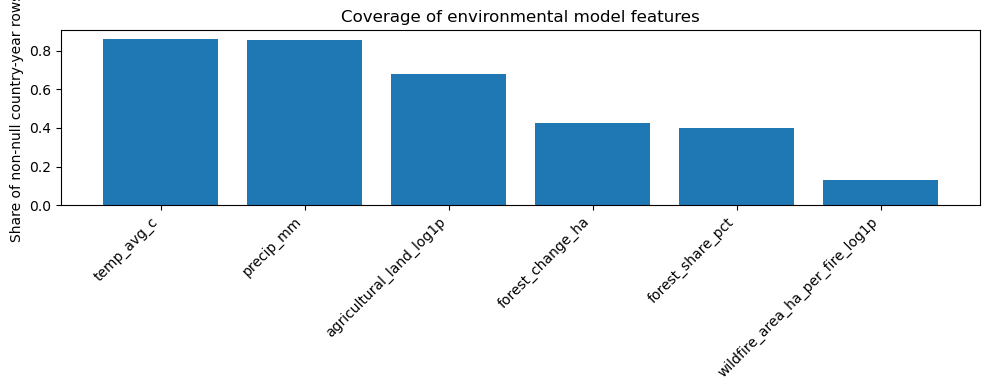

In [19]:

# Coverage diagnostics before biodiversity merge
env_coverage = feature_coverage_summary(env_panel, CLIMATE_CORE_FEATURES)
display(env_coverage)

plt.figure(figsize=(10, 4))
plt.bar(env_coverage["feature"], env_coverage["share_non_null"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share of non-null country-year rows")
plt.title("Coverage of environmental model features")
plt.tight_layout()
plt.show()


In [20]:

# ---------------------------------------------------------
# LOAD BIODIVERSITY DATA AND BUILD LONG PANEL
# ---------------------------------------------------------
if not DEFAULT_BIODIVERSITY_PATH.exists():
    raise FileNotFoundError(
        "The biodiversity dataset is missing. Update DEFAULT_BIODIVERSITY_PATH in the config cell."
    )

df_raw = pd.read_csv(DEFAULT_BIODIVERSITY_PATH)
print("Biodiversity raw shape:", df_raw.shape)
display(df_raw.head())

reference_columns = list(df_raw.columns)
year_columns = [col for col in reference_columns if str(col).isdigit()]
reference_columns_set = set(reference_columns)

static_numeric_features = ["latitude", "longitude"]

static_categorical_features = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units"
]

identifier_columns = ["id", "binomial", "common_name", "location", "country"]

leakage_columns = [
    "n_obs",
    "first_obs_year",
    "last_obs_year",
    "time_span",
    "n_gaps",
    "max_gap",
    "continuity_ratio",
    "zero_count",
    "zero_share",
    "years_since_last_obs"
]

static_numeric_features = [c for c in static_numeric_features if c in reference_columns_set]
static_categorical_features = [c for c in static_categorical_features if c in reference_columns_set]
identifier_columns = [c for c in identifier_columns if c in reference_columns_set]
leakage_columns = [c for c in leakage_columns if c in reference_columns_set]

bio_long = wide_to_long(df_raw, year_columns)
bio_long["country_norm"] = bio_long["country"].apply(normalize_country_name)

print("bio_long shape:", bio_long.shape)
display(bio_long.head())


Biodiversity raw shape: (49, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,27563,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (inside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1429,5.4622,3.5247,3.2330,3.5247,3.5247,9.2437,8.1933,9.0686,13.8655,7.1429,9.6639,8.1933,5.8590,5.8824,14.6125,22.2689,20.7400,22.6891,37.3950,36.1345,50.5019,58.8235,37.3950,37.3950,54.2017,59.2437,57.9832,61.7647,92.437,74.3697,100.0000,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,27564,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (outside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0769,17.5824,18.6813,18.6813,24.1758,29.6703,31.8681,30.7692,38.4615,40.6593,37.3626,41.7582,46.1538,48.3516,72.5275,76.9231,92.3077,91.2088,90.1099,104.3956,105.4945,120.8791,136.2637,118.6813,135.1648,164.8352,200.0000,218.6813,236.2637,267.033,253.8462,327.4725,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,27565,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Sweden,sweden,Sweden,Europe,Europe and Central Asia,Central and Western Europe,64.444593,15.165737,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398.0000,380.0000,328.0000,319.0000,313.0000,343.0000,386.0000,431.0000,425.0000,444.0000,511.0000,575.0000,654.0000,669.0000,751.0000,715.0000,648.0000,587.0000,498.0000,523.0000,584.000,676.0000,687.0000,1,NaN,23.0,1998.0,2020.0,23.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
3,27566,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Norway,norway,Norway,Europe,Europe and Central Asia,Central and Western Europe,64.867984,12.439186,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

bio_long shape: (1349, 60)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm
1479,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,Yellow-footed Rock-wallaby|australia,3.610918,australia
1480,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,Yellow-footed Rock-wallaby|australia,3.044522,australia
1523,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,Moose|canada,4.406719,canada
1528,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,Yellow-footed Rock-wallaby|australia,3.091042,australia
1529,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,Yellow-footed Rock-wallaby|australia,3.367296,australia


In [21]:

# ---------------------------------------------------------
# COUNTRY OVERLAP DIAGNOSTICS
# ---------------------------------------------------------
bio_countries = set(bio_long["country_norm"].dropna().unique())
env_countries = set(env_panel["country_norm"].dropna().unique())

only_bio = sorted(bio_countries - env_countries)
only_env = sorted(env_countries - bio_countries)

print("Countries only in biodiversity:", len(only_bio))
print("Countries only in environment panel:", len(only_env))

display(pd.DataFrame({"country_only_in_biodiversity": only_bio[:50]}))
display(pd.DataFrame({"country_only_in_environment": only_env[:50]}))


Countries only in biodiversity: 0
Countries only in environment panel: 237


,country_only_in_biodiversity


,country_only_in_environment
0,afghanistan
1,albania
2,algeria
3,american samoa
4,andorra
5,angola
6,anguilla
7,antigua and barbuda
8,argentina
9,armenia


In [22]:

# ---------------------------------------------------------
# MERGE BIODIVERSITY + ENVIRONMENT
# ---------------------------------------------------------
model_long_pre_lags = bio_long.merge(
    env_panel,
    on=["country_norm", "Year"],
    how="left"
)

merge_coverage = feature_coverage_summary(model_long_pre_lags, CLIMATE_CORE_FEATURES, group_col="series_id")
display(merge_coverage)

print("model_long_pre_lags shape:", model_long_pre_lags.shape)
display(model_long_pre_lags.head())


,feature,non_null_rows,share_non_null,countries_with_data,year_min_with_data,year_max_with_data
4,agricultural_land_log1p,1349,1.000000,10,1980,2020
1,precip_mm,1349,1.000000,10,1980,2020
0,temp_avg_c,1349,1.000000,10,1980,2020
2,forest_share_pct,1312,0.972572,10,1990,2020
3,forest_change_ha,1297,0.961453,10,1991,2020
5,wildfire_area_ha_per_fire_log1p,439,0.325426,10,2012,2020


model_long_pre_lags shape: (1349, 68)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p
0,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,Yellow-footed Rock-wallaby|australia,3.610918,australia,22.476896,411.99690,NaN,NaN,495638000.0,20.021356,NaN,NaN
1,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,Yellow-footed Rock-wallaby|australia,3.044522,australia,22.476896,411.99690,NaN,NaN,495638000.0,20.021356,NaN,NaN
2,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,Moose|canada,4.406719,canada,-2.742507,645.53790,NaN,NaN,61290000.0,17.931127,NaN,NaN
3,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,Yellow-footed Rock-wallaby|australia,3.091042,australia,21.975897,524.84894,NaN,NaN,495565000.0,20.021209,NaN,NaN
4,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,Yellow-footed Rock-wallaby|australia,3.367296,australia,21.975897,524.84894,NaN,NaN,495565000.0,20.021209,NaN,NaN


In [23]:

# ---------------------------------------------------------
# POPULATION LAG FEATURES
# ---------------------------------------------------------
def add_lag_features(long_df, n_lags=4):
    long_df = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = long_df.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"] = long_df.groupby("series_id")["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]

    long_df["rolling_mean_3"] = (
        grouped_pop.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )

    long_df["rolling_std_3"] = (
        grouped_pop.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    long_df["population_difference"] = long_df["lag_1"] - long_df["lag_2"]

    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) /
        long_df["lag_2"].replace(0, np.nan)
    )
    long_df["population_growth_rate"] = (
        long_df["population_growth_rate"]
        .replace([np.inf, -np.inf], np.nan)
    )

    lag_needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    out = long_df.dropna(subset=lag_needed).copy()

    return out

model_long = add_lag_features(model_long_pre_lags, n_lags=N_LAGS)

print("Rows before lags:", len(model_long_pre_lags))
print("Rows after lags:", len(model_long))
display(model_long.head())


Rows before lags: 1349
Rows after lags: 1309


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p,lag_1,lag_2,lag_3,lag_4,prev_year,year_gap_from_prev,rolling_mean_3,rolling_std_3,population_difference,population_growth_rate
140,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1994,99.0,Helmeted Honeyeater|australia,4.605170,australia,22.029740,324.84503,17.408653,-166735.94,469143000.0,19.966418,NaN,NaN,85.0,75.0,66.0,70.0,1993.0,1.0,1.666667,1.154701,10.0,0.133333
173,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1995,100.0,Helmeted Honeyeater|australia,4.615121,australia,21.740072,509.56027,17.386976,-166735.94,463388000.0,19.954075,NaN,NaN,99.0,85.0,75.0,66.0,1994.0,1.0,4.666667,4.041452,14.0,0.164706
212,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1996,105.0,Helmeted Honeyeater|australia,4.663439,australia,22.214340,437.56897,17.365301,-166735.94,465230000.0,19.958042,NaN,NaN,100.0,99.0,85.0,75.0,1995.0,1.0,1.333333,1.527525,1.0,0.010101
251,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1997,95.0,Helmeted Honeyeater|australia,4.564348,australia,21.928260,510.72460,17.343624,-166735.94,462233000.0,19.951580,NaN,NaN,105.0,100.0,99.0,85.0,1996.0,1.0,5.666667,2.886751,5.0,0.050000
293,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oc

In [24]:

# ---------------------------------------------------------
# FEATURE BUNDLES
# ---------------------------------------------------------
EXPERIMENTS = {
    "forecast_baseline": {
        "use_lagged_frame": True,
        "include_lags": True,
        "include_environment": False,
        "include_static_metadata": True,
        "description": "Lag-based biodiversity forecasting baseline"
    },
    "forecast_plus_environment": {
        "use_lagged_frame": True,
        "include_lags": True,
        "include_environment": True,
        "include_static_metadata": True,
        "description": "Lag-based biodiversity forecasting + environmental features"
    },
    "environment_only_global": {
        "use_lagged_frame": False,
        "include_lags": False,
        "include_environment": True,
        "include_static_metadata": True,
        "description": "No biodiversity lags; metadata + environment only"
    },
}

def build_feature_columns(
    df,
    include_lags=True,
    include_environment=True,
    include_static_metadata=True,
    static_numeric_features=None,
    static_categorical_features=None,
    n_lags=4,
):
    static_numeric_features = static_numeric_features or []
    static_categorical_features = static_categorical_features or []

    common_numeric = ["Year"]
    if include_static_metadata:
        common_numeric += [c for c in static_numeric_features if c in df.columns]

    lag_numeric = [
        *[f"lag_{i}" for i in range(1, n_lags + 1)],
        "year_gap_from_prev",
        "rolling_mean_3",
        "rolling_std_3",
        "population_difference",
        "population_growth_rate",
    ]
    lag_numeric = [c for c in lag_numeric if c in df.columns]

    env_numeric = [c for c in CLIMATE_CORE_FEATURES if c in df.columns]

    categorical = []
    if include_static_metadata:
        categorical = [c for c in static_categorical_features if c in df.columns]

    numeric_features = common_numeric.copy()
    if include_lags:
        numeric_features += lag_numeric
    if include_environment:
        numeric_features += env_numeric

    feature_columns = numeric_features + categorical

    return {
        "numeric_features": numeric_features,
        "categorical_features": categorical,
        "feature_columns": feature_columns,
        "environment_features": env_numeric,
    }


In [25]:

# ---------------------------------------------------------
# MODELLING HELPERS
# ---------------------------------------------------------
def make_preprocessor(numeric_features, categorical_features):
    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numeric_features
            )
        )

    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        )

    return ColumnTransformer(transformers=transformers)


def get_model_grid(preprocessor):
    models = {
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {
                "model__n_estimators": [200],
                "model__max_depth": [8, None],
                "model__min_samples_leaf": [1, 3],
            }
        )
    }

    if HAS_XGBOOST:
        models["XGBoost"] = (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    tree_method="hist",
                    n_jobs=-1,
                    eval_metric="mae",
                ))
            ]),
            {
                "model__n_estimators": [200],
                "model__max_depth": [3, 6],
                "model__learning_rate": [0.05, 0.1],
                "model__subsample": [0.8, 1.0],
            }
        )
    else:
        models["HistGBR_fallback"] = (
            Pipeline([
                ("prep", preprocessor),
                ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
            ]),
            {
                "model__max_depth": [3, 6, None],
                "model__learning_rate": [0.03, 0.1],
                "model__max_iter": [200],
            }
        )

    return models


def get_permutation_importance_df(estimator, X_test, y_test_log, feature_columns, n_repeats=10):
    result = permutation_importance(
        estimator,
        X_test,
        y_test_log,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    out = pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def run_model_comparison(df, feature_columns, categorical_features, label="experiment"):
    train_df, test_df, test_year_values = temporal_split(df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["log_population"].copy()

    X_test = test_df[feature_columns].copy()
    y_test = test_df["Population"].copy()
    y_test_log = test_df["log_population"].copy()

    cv_years = sorted(train_df["Year"].unique())
    split_year = cv_years[int(len(cv_years) * 0.8)]

    cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
    cv_val_idx = np.where(train_df["Year"] > split_year)[0]
    cv_splits = [(cv_train_idx, cv_val_idx)]

    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    models = get_model_grid(preprocessor)

    results = []
    importance_tables = {}
    fitted_models = {}

    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv_splits,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        results.append({
            "feature_set": label,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_years": ", ".join(map(str, test_year_values)),
        })

        imp_df = get_permutation_importance_df(
            estimator=grid.best_estimator_,
            X_test=X_test,
            y_test_log=y_test_log,
            feature_columns=feature_columns,
            n_repeats=10,
        )
        imp_df["feature_set"] = label
        imp_df["model"] = model_name
        importance_tables[model_name] = imp_df
        fitted_models[model_name] = grid.best_estimator_

    return pd.DataFrame(results), importance_tables, fitted_models


In [26]:

# ---------------------------------------------------------
# RUN GLOBAL EXPERIMENTS
# ---------------------------------------------------------
all_results = []
all_importances = []
fitted_global_models = {}

for exp_name, exp_cfg in EXPERIMENTS.items():
    frame = model_long if exp_cfg["use_lagged_frame"] else model_long_pre_lags

    feature_bundle = build_feature_columns(
        frame,
        include_lags=exp_cfg["include_lags"],
        include_environment=exp_cfg["include_environment"],
        include_static_metadata=exp_cfg["include_static_metadata"],
        static_numeric_features=static_numeric_features,
        static_categorical_features=static_categorical_features,
        n_lags=N_LAGS,
    )

    results_df, importance_tables, fitted_models = run_model_comparison(
        df=frame,
        feature_columns=feature_bundle["feature_columns"],
        categorical_features=feature_bundle["categorical_features"],
        label=exp_name
    )

    all_results.append(results_df)

    for model_name, imp_df in importance_tables.items():
        all_importances.append(imp_df)

    fitted_global_models[exp_name] = {
        "models": fitted_models,
        "feature_bundle": feature_bundle,
        "frame": frame,
    }

results_df = pd.concat(all_results, ignore_index=True).sort_values(["NMAE", "feature_set", "model"])
importance_df = pd.concat(all_importances, ignore_index=True)

display(results_df)


,feature_set,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
0,forecast_baseline,RandomForest,"{'model__max_depth': None, 'model__min_samples...",5.636330,15.219747,0.162521,0.162521,0.920917,1065,244,"2016, 2017, 2018, 2019, 2020"
2,forecast_plus_environment,RandomForest,"{'model__max_depth': None, 'model__min_samples...",5.877078,15.963142,0.169463,0.169463,0.932893,1065,244,"2016, 2017, 2018, 2019, 2020"
1,forecast_baseline,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",11.646822,43.716743,0.335831,0.335831,0.954525,1065,244,"2016, 2017, 2018, 2019, 2020"
3,forecast_plus_environment,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",12.683552,46.851914,0.365725,0.365725,1.001444,1065,244,"2016, 2017, 2018, 2019, 2020"
5,environment_only_global,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",12.985919,40.881002,0.374444,0.374444,1.074452,1105,244,"2016, 2017, 2018, 2019, 2020"
4,environment_only_global,RandomForest,"{'model__max_depth': None, 'model__min_samples...",13.102020,41.817455,0.377791,0.377791,1.066308,1105,244,"2016, 2017, 2018, 2019, 2020"


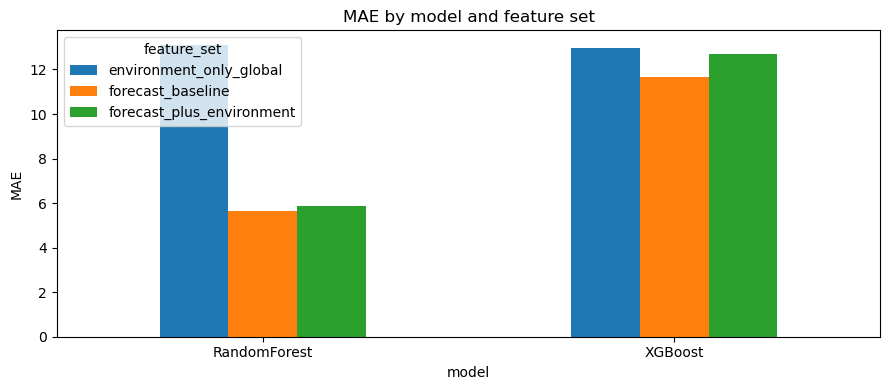

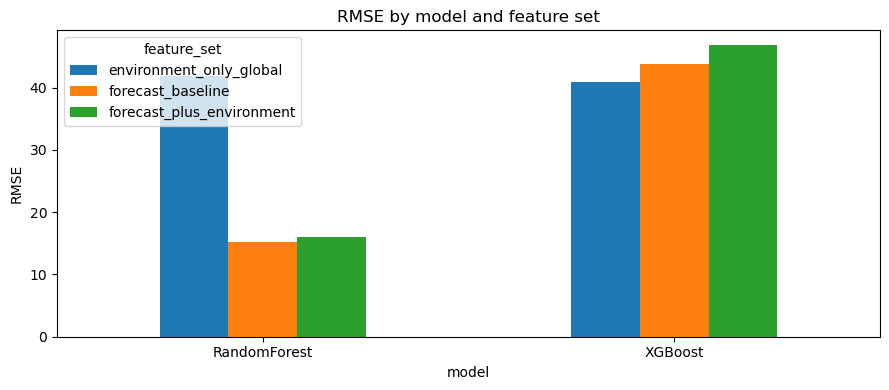

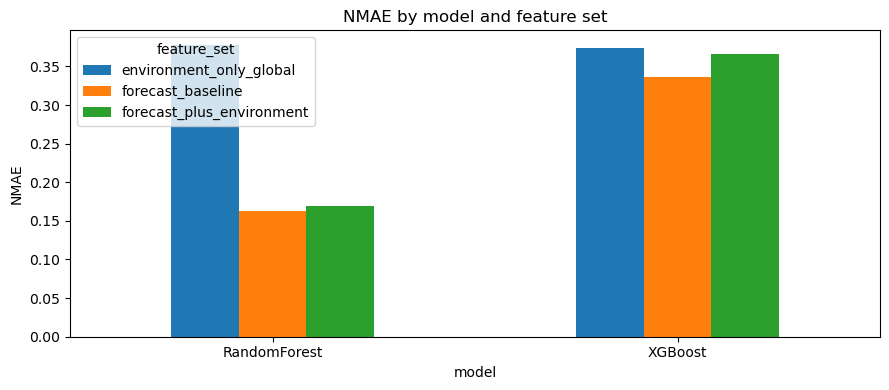

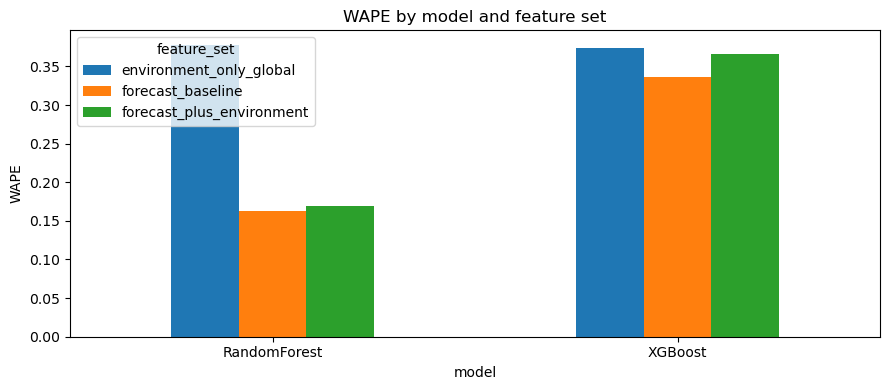

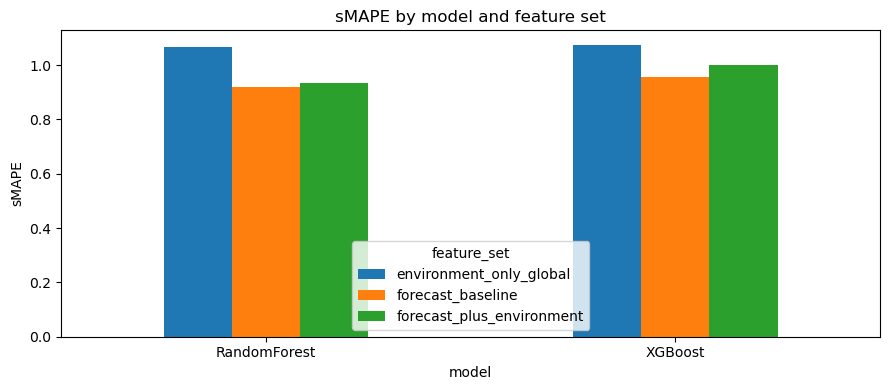

In [27]:

# ---------------------------------------------------------
# PERFORMANCE VISUALS
# ---------------------------------------------------------
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    pivot = results_df.pivot(index="model", columns="feature_set", values=metric)
    ax = pivot.plot(kind="bar", figsize=(9, 4), rot=0, title=f"{metric} by model and feature set")
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()


,feature,importance_mean,importance_std,feature_set,model
45,wildfire_area_ha_per_fire_log1p,0.001280,0.000745,forecast_plus_environment,RandomForest
48,forest_share_pct,0.000562,0.000592,forecast_plus_environment,RandomForest
51,temp_avg_c,0.000338,0.000605,forecast_plus_environment,RandomForest
52,forest_change_ha,0.000083,0.000096,forecast_plus_environment,RandomForest
58,agricultural_land_log1p,-0.000268,0.000187,forecast_plus_environment,RandomForest
59,precip_mm,-0.000573,0.001734,forecast_plus_environment,RandomForest
68,forest_share_pct,0.003251,0.001060,forecast_plus_environment,XGBoost
72,temp_avg_c,0.001414,0.001772,forecast_plus_environment,XGBoost
75,wildfire_area_ha_per_fire_log1p,0.000761,0.000537,forecast_plus_environment,XGBoost
82,agricultural_land_log1p,0.000000,0.000000,forecast_plus_environment,XGBoost


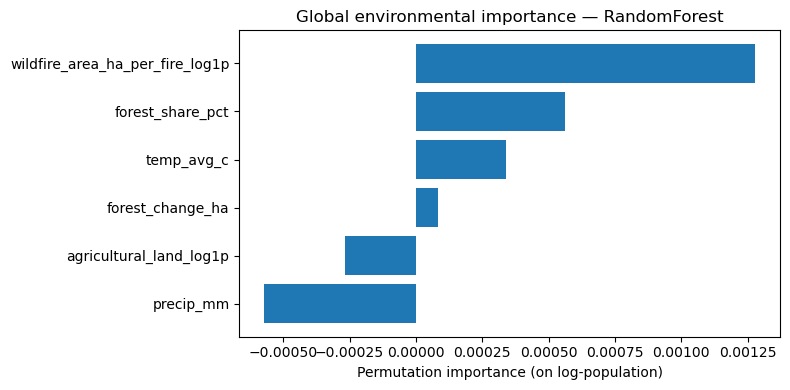

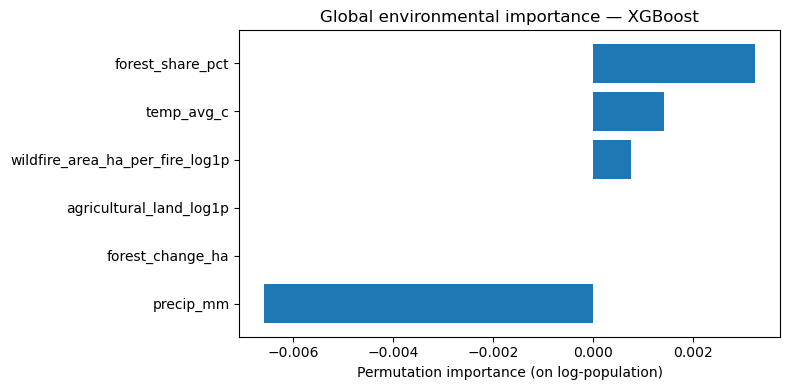

In [28]:

# ---------------------------------------------------------
# GLOBAL ENVIRONMENTAL PERMUTATION IMPORTANCE
# ---------------------------------------------------------
global_env_importance = (
    importance_df[
        (importance_df["feature_set"] == "forecast_plus_environment") &
        (importance_df["feature"].isin(CLIMATE_CORE_FEATURES))
    ]
    .sort_values(["model", "importance_mean"], ascending=[True, False])
)

display(global_env_importance)

for model_name in global_env_importance["model"].unique():
    top_plot = (
        global_env_importance[global_env_importance["model"] == model_name]
        .sort_values("importance_mean", ascending=True)
    )

    plt.figure(figsize=(8, 4))
    plt.barh(top_plot["feature"], top_plot["importance_mean"])
    plt.title(f"Global environmental importance — {model_name}")
    plt.xlabel("Permutation importance (on log-population)")
    plt.tight_layout()
    plt.show()



## 2. Single-population driver analysis (no biodiversity lags, no non-climatic metadata)

This section isolates one population and fits a model using **only environmental features**.  
Goal: identify the **top 3 environmental drivers** of the population trend.

The ranking is based on:
1. **Permutation importance on the held-out years** for that population.
2. A **directional what-if score**: predicted population change when the feature is moved from its 10th to its 90th percentile within the population history.


In [29]:

# ---------------------------------------------------------
# SELECT A POPULATION FOR LOCAL DRIVER ANALYSIS
# ---------------------------------------------------------
def get_series_metadata(df, series_id):
    cols = [
        "series_id", "binomial", "common_name", "class", "family",
        "country", "location", "units", "t_realm", "t_biome", "ipbes_subregion"
    ]
    cols = [c for c in cols if c in df.columns]

    meta = (
        df[df["series_id"] == series_id][cols]
        .drop_duplicates()
        .head(1)
        .T
        .reset_index()
    )
    meta.columns = ["field", "value"]
    return meta


def choose_local_series(df, feature_cols, min_rows=12):
    rows = []
    for series_id, g in df.groupby("series_id"):
        if len(g) < min_rows:
            continue
        coverage = g[feature_cols].notna().mean().mean()
        rows.append({
            "series_id": series_id,
            "rows": len(g),
            "mean_feature_coverage": coverage,
            "last_year": g["Year"].max(),
        })

    candidates = pd.DataFrame(rows)
    if candidates.empty:
        raise ValueError("No series satisfies the minimum length requirement for local analysis.")

    candidates = candidates.sort_values(
        ["mean_feature_coverage", "rows", "last_year"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return candidates

LOCAL_DRIVER_FEATURES = [c for c in CLIMATE_CORE_FEATURES if c in model_long_pre_lags.columns]
local_series_candidates = choose_local_series(
    model_long_pre_lags,
    feature_cols=LOCAL_DRIVER_FEATURES,
    min_rows=LOCAL_MIN_SERIES_ROWS,
)

EXAMPLE_SERIES_ID = local_series_candidates.iloc[0]["series_id"]

print("Selected population for local climate-driver analysis:")
print(EXAMPLE_SERIES_ID)

display(local_series_candidates.head(10))
display(get_series_metadata(model_long_pre_lags, EXAMPLE_SERIES_ID))


Selected population for local climate-driver analysis:
Leadbeater's Possum|australia


,series_id,rows,mean_feature_coverage,last_year
0,Leadbeater's Possum|australia,60,0.908333,2020
1,Plains-wanderer|australia,20,0.908333,2020
2,Wolverine|norway,23,0.898551,2020
3,Wolverine|sweden,23,0.898551,2020
4,Helmeted Honeyeater|australia,51,0.888889,2020
5,Malleefowl|australia,953,0.886849,2020
6,Wolverine|finland,64,0.864583,2020
7,Mountain Pygmy-possum|australia,39,0.799145,2020
8,Yellow-footed Rock-wallaby|australia,80,0.791667,2020
9,Moose|canada,36,0.782407,2020


,field,value
0,series_id,Leadbeater's Possum|australia
1,binomial,Gymnobelideus_leadbeateri
2,common_name,Leadbeater's Possum
3,class,Mammalia
4,family,Petauridae
5,country,australia
6,location,Highlands-Southern Fall
7,units,sample: abundance (counts)
8,t_realm,Australasia
9,t_biome,Temperate broadleaf and mixed forests


In [30]:

# ---------------------------------------------------------
# FIT A CLIMATE-ONLY MODEL FOR ONE POPULATION
# ---------------------------------------------------------
def fit_local_population_driver_model(df, series_id, feature_columns, test_years=5):
    local_df = (
        df[df["series_id"] == series_id]
        .sort_values("Year")
        .copy()
        .reset_index(drop=True)
    )

    local_df = local_df.dropna(subset=["Population", "log_population"]).copy()

    if len(local_df) <= test_years + 4:
        raise ValueError("Selected population has too few rows for train/test split.")

    train_df, test_df, test_year_values = temporal_split(local_df, test_years=test_years)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["log_population"].copy()
    X_test = test_df[feature_columns].copy()
    y_test = test_df["Population"].copy()
    y_test_log = test_df["log_population"].copy()

    preprocessor = make_preprocessor(feature_columns, [])
    models = get_model_grid(preprocessor)

    local_results = []
    local_fitted = {}
    local_importances = {}

    for model_name, (pipeline, param_grid) in models.items():
        # for a single series we keep the model selection lighter and use the same temporal logic
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=[(np.arange(len(train_df) - 2), np.arange(len(train_df) - 2, len(train_df)))],
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        local_results.append({
            "series_id": series_id,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "test_years": ", ".join(map(str, test_year_values)),
        })

        imp_df = get_permutation_importance_df(
            estimator=grid.best_estimator_,
            X_test=X_test,
            y_test_log=y_test_log,
            feature_columns=feature_columns,
            n_repeats=25,
        )
        imp_df["series_id"] = series_id
        imp_df["model"] = model_name

        local_importances[model_name] = imp_df
        local_fitted[model_name] = {
            "estimator": grid.best_estimator_,
            "train_df": train_df,
            "test_df": test_df,
            "local_df": local_df,
        }

    local_results_df = pd.DataFrame(local_results).sort_values("NMAE").reset_index(drop=True)
    best_model_name = local_results_df.iloc[0]["model"]

    return local_results_df, local_fitted, local_importances, best_model_name


local_results_df, local_fitted, local_importances, LOCAL_BEST_MODEL = fit_local_population_driver_model(
    df=model_long_pre_lags,
    series_id=EXAMPLE_SERIES_ID,
    feature_columns=LOCAL_DRIVER_FEATURES,
    test_years=min(TEST_YEARS, 5),
)

print("Best local model:", LOCAL_BEST_MODEL)
display(local_results_df)
display(local_importances[LOCAL_BEST_MODEL])


Best local model: RandomForest


,series_id,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,test_years
0,Leadbeater's Possum|australia,RandomForest,"{'model__max_depth': 8, 'model__min_samples_le...",2.140928,2.431264,1.284557,1.284557,1.700761,"2016, 2017, 2018, 2019, 2020"
1,Leadbeater's Possum|australia,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",2.227115,2.420665,1.336269,1.336269,1.657735,"2016, 2017, 2018, 2019, 2020"


,feature,importance_mean,importance_std,series_id,model
0,agricultural_land_log1p,2.006722e-02,6.514349e-02,Leadbeater's Possum|australia,RandomForest
1,precip_mm,1.256929e-02,2.136531e-02,Leadbeater's Possum|australia,RandomForest
2,temp_avg_c,6.248640e-03,1.083211e-02,Leadbeater's Possum|australia,RandomForest
3,wildfire_area_ha_per_fire_log1p,2.866943e-03,5.006690e-03,Leadbeater's Possum|australia,RandomForest
4,forest_change_ha,3.286260e-16,1.789630e-16,Leadbeater's Possum|australia,RandomForest
5,forest_share_pct,2.842171e-16,2.131628e-16,Leadbeater's Possum|australia,RandomForest


In [31]:

# ---------------------------------------------------------
# TOP-3 LOCAL ENVIRONMENTAL DRIVERS
# ---------------------------------------------------------
def directional_what_if_score(estimator, X_ref, feature):
    X_low = X_ref.copy()
    X_high = X_ref.copy()

    q10 = X_ref[feature].quantile(0.10)
    q90 = X_ref[feature].quantile(0.90)

    X_low[feature] = q10
    X_high[feature] = q90

    pred_low = np.expm1(estimator.predict(X_low))
    pred_high = np.expm1(estimator.predict(X_high))

    return float(np.mean(pred_high - pred_low))


best_local_estimator = local_fitted[LOCAL_BEST_MODEL]["estimator"]
best_local_full_df = local_fitted[LOCAL_BEST_MODEL]["local_df"]
best_local_test_df = local_fitted[LOCAL_BEST_MODEL]["test_df"]

local_driver_table = local_importances[LOCAL_BEST_MODEL].copy()
local_driver_table["directional_q90_minus_q10_effect"] = local_driver_table["feature"].apply(
    lambda f: directional_what_if_score(
        estimator=best_local_estimator,
        X_ref=best_local_full_df[LOCAL_DRIVER_FEATURES].copy(),
        feature=f,
    )
)

top3_local_drivers = local_driver_table.head(3).copy()
display(top3_local_drivers)


,feature,importance_mean,importance_std,series_id,model,directional_q90_minus_q10_effect
0,agricultural_land_log1p,0.020067,0.065143,Leadbeater's Possum|australia,RandomForest,1.603514
1,precip_mm,0.012569,0.021365,Leadbeater's Possum|australia,RandomForest,-0.150709
2,temp_avg_c,0.006249,0.010832,Leadbeater's Possum|australia,RandomForest,-0.417262


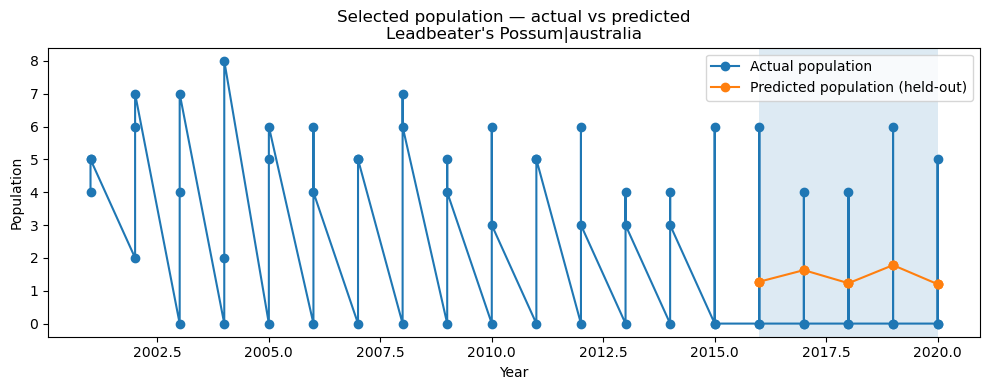

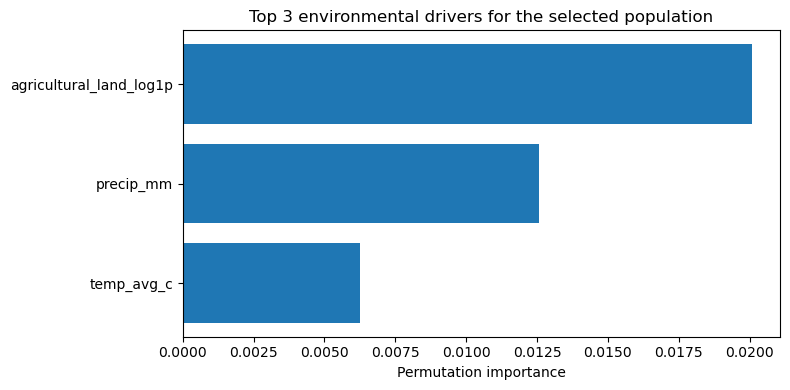

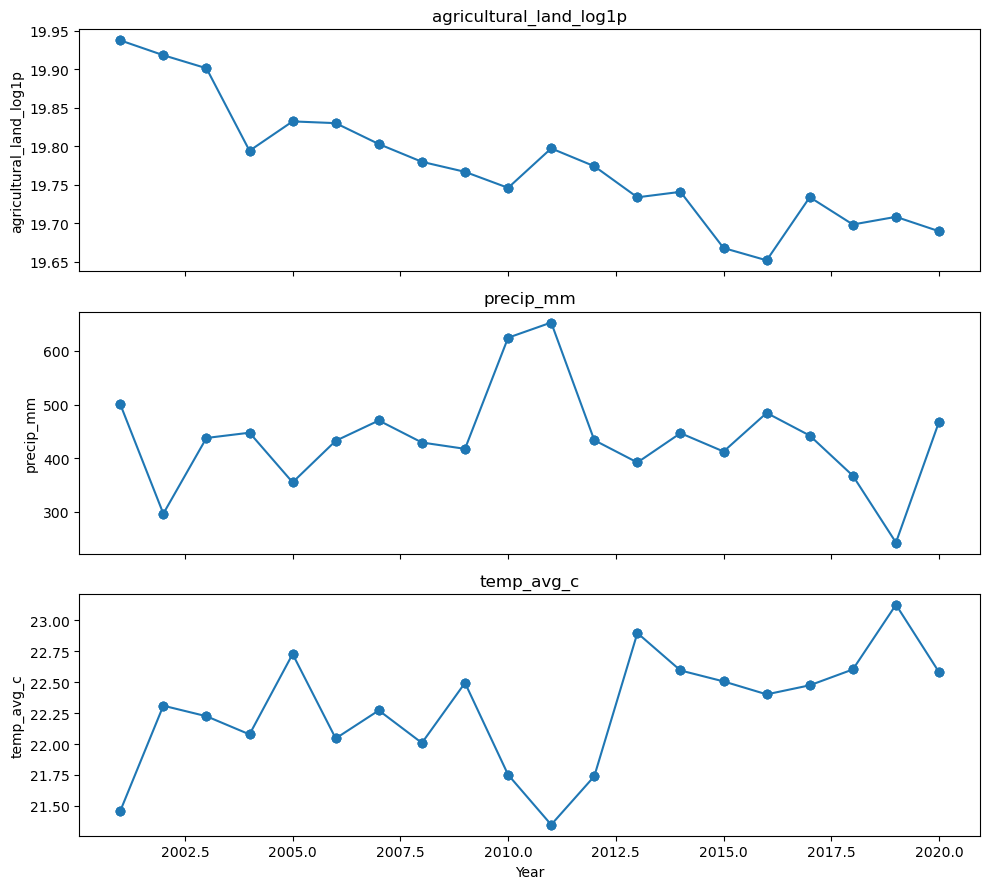

In [32]:

# ---------------------------------------------------------
# VISUALS FOR THE SELECTED POPULATION
# ---------------------------------------------------------
# Predicted vs actual on held-out years
local_test_df = best_local_test_df.copy()
local_test_df["pred_log"] = best_local_estimator.predict(local_test_df[LOCAL_DRIVER_FEATURES])
local_test_df["pred_population"] = np.clip(np.expm1(local_test_df["pred_log"]), a_min=0, a_max=None)

plt.figure(figsize=(10, 4))
plt.plot(best_local_full_df["Year"], best_local_full_df["Population"], marker="o", label="Actual population")
plt.plot(local_test_df["Year"], local_test_df["pred_population"], marker="o", label="Predicted population (held-out)")
plt.axvspan(local_test_df["Year"].min(), local_test_df["Year"].max(), alpha=0.15)
plt.title(f"Selected population — actual vs predicted\n{EXAMPLE_SERIES_ID}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

# Top-3 local driver bar chart
plot_df = top3_local_drivers.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Top 3 environmental drivers for the selected population")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()

# Environmental trajectories for the top-3 drivers
fig, axes = plt.subplots(len(top3_local_drivers), 1, figsize=(10, 3 * len(top3_local_drivers)), sharex=True)
if len(top3_local_drivers) == 1:
    axes = [axes]

for ax, feature in zip(axes, top3_local_drivers["feature"]):
    ax.plot(best_local_full_df["Year"], best_local_full_df[feature], marker="o")
    ax.set_title(feature)
    ax.set_ylabel(feature)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()



## 3. Reading the notebook output

### Use the global results table to answer:
- Do the environmental features improve the lag-based forecasting benchmark?
- Which model benefits most from the environmental block?
- Which environmental categories matter most globally?

### Use the local driver section to answer:
- For one concrete monitored population, which **3 environmental variables** matter most?
- Is the effect direction mainly positive or negative in the model's what-if analysis?
- Does the climate-only/environment-only story align with the observed population trajectory?

### Important interpretation caution
The local driver analysis is **predictive**, not causal proof.  
It tells you which environmental variables are most useful to explain the selected population's trajectory **within the model**, not that they are the only true biological mechanisms.



## 4. Suggested next extension

If you later want a richer notebook without losing clarity, the cleanest next step is:
1. keep this **core environment block** fixed;
2. add **optional pressure features** (e.g. urban share) in a separate experiment;
3. compare **core climate/environment** vs **core + human pressure** rather than mixing everything at once.
